In [43]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from torch.utils.tensorboard import SummaryWriter
from PIL import Image
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns


# 設置設備
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [85]:
import pandas as pd

df = pd.read_csv("taiwanese-food-101/tw_food_101_classes.csv", header=None)

total_classes = df[1].tolist()

print(total_classes)  # 確保讀取正確

['bawan', 'beef_noodles', 'beef_soup', 'bitter_melon_with_salted_eggs', 'braised_napa_cabbage', 'braised_pork_over_rice', 'brown_sugar_cake', 'bubble_tea', 'caozaiguo', 'chicken_mushroom_soup', 'chinese_pickled_cucumber', 'coffin_toast', 'cold_noodles', 'crab_migao', 'deep-fried_chicken_cutlets', 'deep_fried_pork_rib_and_radish_soup', 'dried_shredded_squid', 'egg_pancake_roll', 'eight_treasure_shaved_ice', 'fish_head_casserole', 'fried-spanish_mackerel_thick_soup', 'fried_eel_noodles', 'fried_instant_noodles', 'fried_rice_noodles', 'ginger_duck_stew', 'grilled_corn', 'grilled_taiwanese_sausage', 'hakka_stir-fried', 'hot_sour_soup', 'hung_rui_chen_sandwich', 'intestine_and_oyster_vermicelli', 'iron_egg', 'jelly_of_gravey_and_chicken_feet_skin', 'jerky', 'kung-pao_chicken', 'luwei', 'mango_shaved_ice', 'meat_dumpling_in_chili_oil', 'milkfish_belly_congee', 'mochi', 'mung_bean_smoothie_milk', 'mutton_fried_noodles', 'mutton_hot_pot', 'nabeyaki_egg_noodles', 'night_market_steak', 'nougat',

In [ ]:
import os
import warnings
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

class CustomImageDataset(Dataset):
    def __init__(self, csv_file, root_dir, class_map_file=None, transform=None, subset=None, validation_split=0.1, seed=42):
        """
        Args:
            csv_file (str): 影像數據的 CSV，包含 [Index, Label, ImagePath] 或測試集的 [ImagePath]
            root_dir (str): 影像資料的根目錄
            class_map_file (str, optional): Class 對應的 CSV，包含 [Index, ClassName]，可選
            transform (callable, optional): 圖像轉換，如 ToTensor(), Resize() 等
            subset (str, optional): 選擇 'train'、'validation' 或 'test'
            validation_split (float, optional): 設定驗證集比例（0-1 之間）
            seed (int, optional): 隨機種子，確保可重現性
        """
        self.root_dir = root_dir
        self.transform = transform
        self.subset = subset
        self.seed = seed
        self.is_test_set = subset == "test"

        # 根據子集類型讀取CSV
        if self.is_test_set:
            # 測試集CSV只有一列（圖片路徑）
            self.data_frame = pd.read_csv(csv_file, header=None, names=["ImagePath"])
            print(f"測試集數據載入: {len(self.data_frame)} 筆")
        else:
            # 訓練集和驗證集CSV有兩列（標籤和圖片路徑）
            self.data_frame = pd.read_csv(csv_file, header=None, names=["Index", "ImagePath"])
            print(f"訓練/驗證數據載入: {len(self.data_frame)} 筆")

        # 讀取 Class Map（如果有提供）
        if class_map_file:
            class_map_df = pd.read_csv(class_map_file, header=None, names=["Index", "ClassName"])
            self.int_to_class = {row["Index"]: row["ClassName"] for _, row in class_map_df.iterrows()}
            self.class_to_int = {row["ClassName"]: row["Index"] for _, row in class_map_df.iterrows()}
        else:
            self.int_to_class = None
            self.class_to_int = None

        # 如果不是測試集，進行訓練/驗證拆分
        if not self.is_test_set and subset in ["train", "validation"]:
            train_data, val_data = train_test_split(
                self.data_frame, test_size=validation_split, random_state=self.seed
            )
            self.data_frame = train_data if subset == "train" else val_data
            print(f"{'訓練' if subset == 'train' else '驗證'}集數據: {len(self.data_frame)} 筆")

    def __len__(self):
        return len(self.data_frame)
    
    def __getitem__(self, idx):
        # 根據數據集類型獲取正確的圖片路徑列索引
        if self.is_test_set:
            # 測試集只讀取圖片路徑（第一列）
            img_path = os.path.join(self.root_dir, self.data_frame.iloc[idx, 0])
        else:
            # 訓練/驗證集讀取圖片路徑（第二列）
            img_path = os.path.join(self.root_dir, self.data_frame.iloc[idx, 1])

        retries = 0
        max_retries = 5

        while retries < max_retries:
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", category=UserWarning)
                    image = Image.open(img_path)

                # 修正透明度問題
                if image.mode in ["P", "LA", "RGBA"]:
                    image = image.convert("RGB")
                                
                elif image.mode == "CMYK":
                    image = image.convert("RGB")  # 將 CMYK 轉為 RGB

                if self.transform:
                    image = self.transform(image)

                # 測試集沒有標籤
                if self.is_test_set:
                    return image, -1  # 測試集返回None作為標籤
                else:
                    label = int(self.data_frame.iloc[idx, 0])  # 訓練/驗證集使用第一列作為標籤
                    return image, label

            except Exception as e:
                print(f"⚠️ 警告: 無法讀取 {img_path}，錯誤訊息: {e}")
                retries += 1
                # 如果讀取出錯，嘗試重試
                if retries >= max_retries:
                    print(f"跳過圖片: {img_path}")
                    # 返回一個全零的假圖片來避免返回 None
                    dummy_image = Image.new('RGB', (224, 224), (0, 0, 0))  # 創建一個全黑的圖片
                    dummy_label = -1 if not self.is_test_set else None  # 依據數據集類型設定假標籤
                    if self.transform:
                        dummy_image = self.transform(dummy_image)  # 應用相同的 transform
                    return dummy_image, dummy_label  # 返回默認的無效數據

        # 如果超過最大重試次數還是無法讀取圖片，拋出異常
        raise RuntimeError(f"❌ 無法讀取圖片: {img_path}，已達最大重試次數 {max_retries} 次。")

    def get_class_name(self, label_int):
        """ 傳入數字標籤，回傳對應的類別名稱 """
        if self.int_to_class:
            return self.int_to_class.get(label_int, "Unknown")
        return str(label_int)

    def get_class_int(self, class_name):
        """ 傳入類別名稱，回傳對應的數字標籤 """
        if self.class_to_int:
            return self.class_to_int.get(class_name, -1)
        return -1

In [80]:
csv_path = "taiwanese-food-101/tw_food_101/tw_food_101/tw_food_101_train.csv"  # 訓練數據 CSV
test_csv_path = "taiwanese-food-101/tw_food_101/tw_food_101/tw_food_101_test_list.csv"  # 測試數據 CSV
root_dir = "taiwanese-food-101/tw_food_101/tw_food_101/"  # 影像根目錄
class_map_file = "taiwanese-food-101/tw_food_101_classes.csv"  # Class 標籤對應表

In [81]:
# 設定轉換（對於圖像大小、標準化等處理）
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),  # 增加翻轉機率，通常水平翻轉比較常見
    transforms.RandomRotation(degrees=15),  # 限制旋轉範圍，避免過度扭曲圖片
    transforms.AutoAugment(),  # 可以保留，也可以選擇不使用
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # 使用隨機裁剪來強化模型
    # transforms.RandAugment(),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ViT 預訓練標準化
])

# train_transform = transforms.Compose([
#     transforms.RandomHorizontalFlip(p=0.5),  # 增加翻轉機率，水平翻轉對食物圖片有幫助
#     transforms.RandomRotation(degrees=10),  # 限制旋轉範圍，避免過度扭曲圖片
#     transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # 隨機裁剪，避免過度變形
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # 隨機調整顏色，增強顏色變化
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # 使用 ViT 預訓練標準化
# ])


val_transform = transforms.Compose([
    transforms.Resize((224, 224)), # Vit
    transforms.ToTensor(),  # 轉換為 Tensor
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
])

# 訓練集 (90%)
train_ds = CustomImageDataset(csv_file=csv_path, root_dir=root_dir, class_map_file=class_map_file, 
                              transform=train_transform, subset='train')

# 驗證集 (10%)
val_ds = CustomImageDataset(csv_file=csv_path, root_dir=root_dir, class_map_file=class_map_file, 
                            transform=val_transform, subset='validation')

test_ds = CustomImageDataset(csv_file=test_csv_path, root_dir=root_dir, class_map_file=class_map_file, 
                             transform=val_transform, subset='test')


# 使用 DataLoader
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=4, pin_memory= True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=4, pin_memory= True)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=4, pin_memory= True)


訓練/驗證數據載入: 20372 筆
訓練集數據: 18334 筆
訓練/驗證數據載入: 20372 筆
驗證集數據: 2038 筆
測試集數據載入: 5093 筆


Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/0.jpgReading image: taiwanese-food-101/tw_food_101/tw_food_101/test/32.jpgReading image: taiwanese-food-101/tw_food_101/tw_food_101/test/16.jpg


Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/48.jpgReading image: taiwanese-food-101/tw_food_101/tw_food_101/test/1.jpg

Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/33.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/34.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/2.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/49.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/35.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/50.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/3.jpgReading image: taiwanese-food-101/tw_food_101/tw_food_101/test/36.jpg

Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/4.jpgReading image: taiwanese-f

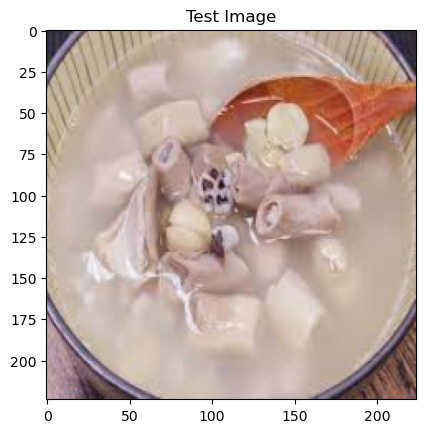

In [83]:
import matplotlib.pyplot as plt
import numpy as np

# 顯示第一個批次中的第一張圖片
for images, labels in test_loader:  # 添加labels參數接收標籤
    print(f"Batch images shape: {images.shape}")
    print(f"Batch labels shape: {labels.shape}")
    print(f"First label in batch: {labels[0]}")  # 這將顯示-1
    
    # 顯示第一張圖片
    first_image = images[0].permute(1, 2, 0).numpy()
    first_image = np.clip(first_image, 0, 1)
    plt.imshow(first_image)
    plt.title(f"Test Image")  # 因為測試集沒有實際標籤
    plt.show()
    break  # 只顯示第一個批次

In [86]:
# # 定義 Vision Transformer 模型
# model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

# model.heads[0] = nn.Sequential(
#     nn.Dropout(p=0.4),  # 加入 Dropout 層
#     nn.Linear(model.heads[0].in_features, len(total_classes))
# )

# model.to(device)

from timm import create_model

model = create_model('swin_base_patch4_window7_224', pretrained=True, num_classes=len(total_classes))
model.to(device)
# 定義損失函數和優化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), weight_decay=0.001, lr=0.00002122)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3, min_lr=1e-6)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
#Vit 80%


# # 定義 Vision Transformer 模型
# model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

# # 修改模型的頭部，增加更多層
# model.heads[0] = nn.Sequential(
#     nn.Dropout(p=0.2),  # 加入 Dropout 層
#     nn.Linear(model.heads[0].in_features, 512),  # 新的全連接層，將特徵維度降低
#     nn.ReLU(),  # 添加 ReLU 激活函數
#     nn.Dropout(p=0.3),  # 進一步加強 Dropout
#     nn.Linear(512, 256),  # 再加一層全連接層
#     nn.ReLU(),  # 添加 ReLU 激活函數
#     nn.Dropout(p=0.4),  # 更強的 Dropout
#     nn.Linear(256, len(total_classes))  # 最後一層輸出層，對應所有類別
# )

# model.to(device)

# # 定義損失函數和優化器
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.AdamW(model.parameters(), weight_decay=0.01, lr=1e-4)

# # 使用 ReduceLROnPlateau 學習率調度器
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3, min_lr=1e-6)

In [ ]:

import warnings
from PIL import Image
from tqdm import tqdm  # ✅ 引入 tqdm 來顯示進度條
torch.cuda.empty_cache()  # 清空 CUDA Cache
torch.cuda.memory_reserved(0)  # 釋放所有 GPU 記憶體

warnings.filterwarnings("ignore", category=UserWarning, module="PIL")

# 自定義 Logger
class EpochLogger:
    def __init__(self):
        self.history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

    def log_epoch(self, epoch, train_loss, train_accuracy, val_loss, val_accuracy, epoch_time):
        self.history["loss"].append(train_loss)
        self.history["accuracy"].append(train_accuracy)
        self.history["val_loss"].append(val_loss)
        self.history["val_accuracy"].append(val_accuracy)

        print(f"\nEpoch {epoch + 1}:")
        print(f"  - Train Loss: {train_loss:.4f}")
        print(f"  - Train Accuracy: {train_accuracy:.4f}")
        print(f"  - Val Loss: {val_loss:.4f}")
        print(f"  - Val Accuracy: {val_accuracy:.4f}")
        print(f"  - Epoch Time: {epoch_time:.2f} seconds", flush=True)  # ✅ 確保即時輸出

# 訓練模型
num_epochs = 100
best_val_accuracy = 0.0
epoch_logger = EpochLogger()

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    start_time = time.time()

    # ✅ 使用 tqdm 來顯示 batch 訓練進度
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)

    for inputs, labels in train_loader_tqdm:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        # ✅ 更新 tqdm 進度條顯示 loss
        train_loader_tqdm.set_postfix(loss=loss.item(), accuracy=correct_train / total_train)

    train_loss /= total_train
    train_accuracy = correct_train / total_train

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        val_loader_tqdm = tqdm(val_loader, desc=f"Validation {epoch+1}/{num_epochs}", leave=False)  # ✅ Validation 也加進度條

        for inputs, labels in val_loader_tqdm:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            # ✅ 更新 tqdm 進度條顯示 loss
            val_loader_tqdm.set_postfix(loss=loss.item(), accuracy=correct_val / total_val)

    val_loss /= total_val
    val_accuracy = correct_val / total_val

    epoch_time = time.time() - start_time
    epoch_logger.log_epoch(epoch, train_loss, train_accuracy, val_loss, val_accuracy, epoch_time)

    # 獲取當前學習率
    # current_lr = scheduler.get_last_lr()[0]  
    # print(f"Current LR: {current_lr:.6f}")

    # scheduler.step(val_loss)

    # ✅ 保存最佳模型
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), "hw2_weight/revise_Deit.pth")

print(f"\n best_val_accuracy: {best_val_accuracy}")
print("\n🎉 Training Complete.")

In [88]:
# 載入Swin Transformer模型
model = create_model(
    'swin_base_patch4_window7_224', 
    pretrained=False,  # 不需要預訓練權重，因為會載入自己的權重
    num_classes=101
)
model = model.to(device)

# 載入訓練好的權重
model.load_state_dict(torch.load("/home/rvl1421/MIngWei/NTUT_Deep_Learning/hw2_weight/revise_Deit.pth", map_location=device))
model.eval()  # 設置為評估模式

# 測試函數
def test_model():
    model.eval()
    all_predictions = []
    
    with torch.no_grad():
        for images, _ in tqdm(test_loader, desc="測試中"):
            images = images.to(device)
            
            # 前向傳播
            outputs = model(images)
            _, predictions = torch.max(outputs, 1)
            
            # 儲存預測結果
            all_predictions.extend(predictions.cpu().numpy())
    
    return all_predictions

# 執行測試
predictions = test_model()

# 創建索引列 (0,1,2,...,n)
indices = list(range(len(predictions)))

# 創建結果DataFrame
results_df = pd.DataFrame({
    'index': indices,
    'label': predictions
})

# 保存結果
results_df.to_csv('test_predictions.csv', index=False)
print(f"預測結果已保存至 test_predictions.csv")

/tmp/ipykernel_2537561/3802584866.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home/rvl1421/MIngWei/NTUT_Deep_Learning/hw2_weight/

Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/16.jpgReading image: taiwanese-food-101/tw_food_101/tw_food_101/test/32.jpgReading image: taiwanese-food-101/tw_food_101/tw_food_101/test/0.jpg


Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/48.jpgReading image: taiwanese-food-101/tw_food_101/tw_food_101/test/1.jpg

Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/33.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/34.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/2.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/49.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/35.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/50.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/3.jpgReading image: taiwanese-food-101/tw_food_101/tw_food_101/test/36.jpg

Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/4.jpgReading image: taiwanese-f

測試中:   0%|          | 1/319 [00:00<04:02,  1.31it/s]

Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/67.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/86.jpgReading image: taiwanese-food-101/tw_food_101/tw_food_101/test/68.jpg

Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/126.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/69.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/127.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/160.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/70.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/71.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/72.jpgReading image: taiwanese-food-101/tw_food_101/tw_food_101/test/161.jpg

Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/176.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/73.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/87.jpg
Reading image: 

測試中:   2%|▏         | 5/319 [00:00<00:49,  6.39it/s]

...

Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/5041.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/5090.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/5074.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/5091.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/5075.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/5092.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/5042.jpeg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/5076.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/5043.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/5077.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/5078.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/5079.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/5044.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/

測試中:  99%|█████████▉| 316/319 [01:31<00:00,  4.88it/s]

Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/5083.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/5084.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/5085.png
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/5086.jpg
Reading image: taiwanese-food-101/tw_food_101/tw_food_101/test/5087.jpg


測試中: 100%|██████████| 319/319 [01:34<00:00,  3.39it/s]


預測結果已保存至 test_predictions.csv
